# Lab | Introduction to LoRA Tuning using PEFT from Hugging Face
<!-- ### Fine-tune a Foundational Model effortlessly -->

**Note:** This is more or less the same notebook you saw in the previous lesson, but that is ok. This is an LLM fine-tuning lab. In class we used a set of datasets and models, and in the labs you are required to change the LLMs models and the datasets including the pre-processing pipelines.


# LoRA Tuning

In this notebook you are being introduced to how to apply LoRA Tuning with the PEFT library to a pre-trained model.

For a complete list of Models compatible with PEFT refer to their [documentation](https://huggingface.co/docs/peft/main/en/index#supported-methods).

A short sample of models families available to be trained with PEFT are: Bloom, Llama, GPT-J, GPT-2, BERT... and more. Hugging Face is working hard to bring more Models to the Library.

## Brief introduction to LoRA Tuning.
LoRA is a re-parameterization technique. Its operation is simple, complex, and brilliant at the same time. It involves reducing the size of the matrices to be trained by dividing them in such a way that when multiplied, they yield the original matrix.

The weights that are modified are those of the reduced matrices, not the original matrix. It's better visualized in an image.

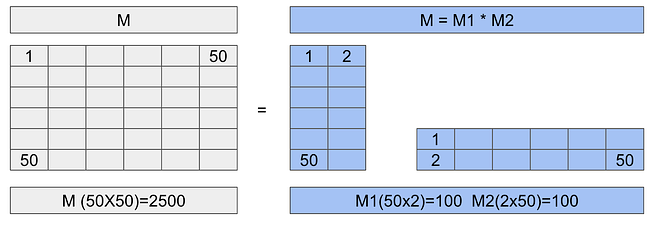

We have an original matrix of 50x50, which means we would have to modify about 2500 parameters. However, as we know, if we multiply two matrices of (2x50) and (50x2), we obtain a 50x50 matrix. Yet, these two matrices are formed by only 100 parameters each. In other words, for the reduced matrices, we need to modify a total of 200 parameters compared to the 2500 of the original matrix. This represents a 92% reduction, and the larger the original matrix, the greater the percentage of savings.

In Language Models like GPT-3 or any of the current ones with LoRA, it's possible that we only need to train about 0.02% of the original parameters. This varies for each model. The best part is that the obtained result is very similar to that of full fine-tuning, in some cases, it can even be better.

# Load the PEFT and Datasets Libraries.

The PEFT library contains the Hugging Face implementation of differente fine-tuning techniques, like LoRA Tuning.

Using the Datasets library we have acces to a huge amount of Datasets.

In [1]:
!pip install -q peft==0.8.2
!pip install -q datasets==2.16.1
!pip install ipywidgets==7.7.5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.1/507.1 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.4/166.4 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 15.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2023.10.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.9/246.9 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 134.9 MB/s eta 0:00:00
  Attempting uninstall: jupyterlab-widgets
    Found existing installation: jupyterla

From the transformers library we import the necesary classes to import the model and the tokenizer.

Then we can load the Tokenizer and the model.

Bloom is one of the smallest and smarter model available to be trained with PEFT Library using Prompt Tuning. You can use either of the models in the Bloom Family, I encorage you to use at least two of them and see the differences.

I'm using the smallest one just to spend less time trainig, and avoid memory problems in Colab.

In [1]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model_name = "bigscience/bloom-560m"

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

# BLOOM is a decoder-only model, use left padding for generation
tokenizer.padding_side = "left"

# Keep BLOOM's original padding setup
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Load model
foundation_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    torch_dtype=torch.float32   # changed from float16 for stability
)

# Make sure model knows the correct padding token
foundation_model.config.pad_token_id = tokenizer.pad_token_id

# Verification checks
print("Tokenizer vocab size:", len(tokenizer))
print("Model embedding size:", foundation_model.get_input_embeddings().weight.shape[0])
print("Padding token ID:", tokenizer.pad_token_id)
print("EOS token ID:", tokenizer.eos_token_id)
print("Model device:", foundation_model.device)

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/222 [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 14.5MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

Tokenizer vocab size: 250680
Model embedding size: 250880
Padding token ID: 3
EOS token ID: 2
Model device: cuda:0


## Inference with the pre-trained model.
I'm going to do a test with the pre-trained model without fine-tuning, to see if something changes after the fine-tuning.

In [2]:
#this function returns the outputs from the model received, and inputs.
def get_outputs(model, inputs, max_new_tokens=100):  # #play with this function inputs and see if you get something interesting
    model.eval()

    with torch.no_grad():
        outputs = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=max_new_tokens,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
            do_sample=False,
            repetition_penalty=1.1
        )

    return outputs

The dataset used for the fine-tuning contains prompts to be used with Large Language Models.

I'm going to request the pre-trained model that acts like a motivational coach.

In [3]:
# --- BASELINE PERFORMANCE CHECK ---
# We test the model BEFORE fine-tuning to see how the original model (Foundation Model) handles the instruction "I want you to act like a motivational coach".

# 1. Tokenize the input string.
# We move the tensors to the same device (GPU/CPU) as the foundation_model to avoid 'device mismatch' errors.
inputs = tokenizer("I want you to act like a motivational coach: ", return_tensors="pt").to(foundation_model.device)

# 2. Run the inference using our customized get_outputs function.
# We limit max_new_tokens to 50 for a quick look at how the base model completes this sentence.
foundational_outputs_sentence = get_outputs(foundation_model, inputs, max_new_tokens=50)

# 3. Decode the numerical tokens back into human-readable text.
# skip_special_tokens=True removes tokens like <pad> or </s> from the printed result.
import textwrap

output_text = tokenizer.batch_decode(foundational_outputs_sentence, skip_special_tokens=True)[0]

print("--- Foundation Model Output ---")
print(textwrap.fill(output_text, width=100))

--- Foundation Model Output ---
I want you to act like a motivational coach:  I am not going anywhere unless there is something that
will make me feel good about myself." In the end, she was able and willing enough for her husband's
advice. She had no idea how much he loved him until his death in 2006


Not sure if the answer is correct or not, but for sure is not a prompt. We need to train our model if we want that acts like a motivational coach.

# Preparing the Dataset.
The Dataset used is:

https://huggingface.co/datasets/databricks/databricks-dolly-15k

In [4]:
# Import required library
from datasets import load_dataset


# ------------------------------------------------------------
# STEP 1: Load the dataset
# ------------------------------------------------------------

# Databricks Dolly 15k is an instruction-following dataset.
# It contains:
# - instruction: what the user wants
# - context: optional extra information
# - response: expected answer

dataset_name = "databricks/databricks-dolly-15k"

data = load_dataset(
    dataset_name,
    split="train"
)

# Display one example before processing
# This helps us understand the original dataset structure.
print(data[0])



# ------------------------------------------------------------
# STEP 2: Convert dataset into training format
# ------------------------------------------------------------

def tokenize_function(samples):

    """
    Convert raw dataset examples into a format suitable
    for causal language model fine-tuning.

    Training format:

    ### Instruction:
    User request

    ### Context:
    Additional information (if available)

    ### Response:
    Expected answer
    """

    texts = []


    # Create formatted prompts
    for instruction, context, response in zip(
        samples["instruction"],
        samples["context"],
        samples["response"]
    ):


        # Include context only when it exists
        if context:

            text = f"""### Instruction:
{instruction}

### Context:
{context}

### Response:
{response}
"""

        else:

            text = f"""### Instruction:
{instruction}

### Response:
{response}
"""


        texts.append(text)



    # --------------------------------------------------------
    # STEP 3: Tokenization
    # --------------------------------------------------------

    contents = tokenizer(
        texts,

        # Cut sequences longer than max_length
        truncation=True,

        # Make all examples the same size
        padding="max_length",

        # Suitable length for Colab GPU memory
        max_length=256
    )



    # --------------------------------------------------------
    # STEP 4: Create training labels
    # --------------------------------------------------------

    # For causal language models:
    # labels are the text the model should learn to predict.
    #
    # We ignore the instruction part (-100)
    # and train mainly on the response.

    contents["labels"] = []


    for ids, text in zip(
        contents["input_ids"],
        texts
    ):

        labels = ids.copy()


        # Find the beginning of the answer
        response_position = text.find("### Response:")


        # Tokenize everything before the answer
        prompt_tokens = tokenizer(
            text[:response_position + len("### Response:")],
            truncation=True,
            max_length=256
        )["input_ids"]


        # Ignore instruction/context tokens during training
        labels[:len(prompt_tokens)] = [-100] * len(prompt_tokens)


        # Ignore padding tokens
        labels = [
            token if token != tokenizer.pad_token_id else -100
            for token in labels
        ]


        contents["labels"].append(labels)


    return contents



# ------------------------------------------------------------
# STEP 5: Apply tokenization to the complete dataset
# ------------------------------------------------------------

# IMPORTANT: padding_side was set to "left" earlier for generation. For training,
# padding must be on the right -- otherwise the label-masking logic above (which
# assumes the prompt tokens start at index 0) becomes misaligned for any example
# shorter than max_length, since left-padding pushes the real content to the end.
tokenizer.padding_side = "right"

tokenized_data = data.map(
    tokenize_function,
    batched=True
)

# Restore left-padding for generation, used everywhere else in this notebook.
tokenizer.padding_side = "left"



# ------------------------------------------------------------
# STEP 6: Select training samples
# ------------------------------------------------------------

# Using 2000 examples:
# - Faster than the full 15k dataset
# - Enough data to observe LoRA improvement

train_sample = tokenized_data.select(
    range(2000)
)



# ------------------------------------------------------------
# STEP 7: Remove original text columns
# ------------------------------------------------------------

# Trainer only needs numerical tensors.
# Keep:
# input_ids
# attention_mask
# labels

train_sample = train_sample.remove_columns(
    [
        "instruction",
        "context",
        "response",
        "category"
    ]
)



# ------------------------------------------------------------
# STEP 8: Convert to PyTorch format
# ------------------------------------------------------------

train_sample.set_format("torch")



# ------------------------------------------------------------
# STEP 9: Check final dataset
# ------------------------------------------------------------

display(train_sample)

Generating train split: 0 examples [00:00, ? examples/s]

{'instruction': 'When did Virgin Australia start operating?', 'context': "Virgin Australia, the trading name of Virgin Australia Airlines Pty Ltd, is an Australian-based airline. It is the largest airline by fleet size to use the Virgin brand. It commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route. It suddenly found itself as a major airline in Australia's domestic market after the collapse of Ansett Australia in September 2001. The airline has since grown to directly serve 32 cities in Australia, from hubs in Brisbane, Melbourne and Sydney.", 'response': 'Virgin Australia commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route.', 'category': 'closed_qa'}


Map:   0%|          | 0/15011 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 2000
})

In [5]:
# Show one sample in readable format

# Switch dataset format (important!)
train_sample.set_format("python")

# Get one sample
sample = train_sample[0]

# Decode tokens back to text
decoded_text = tokenizer.decode(sample["input_ids"], skip_special_tokens=True)

print("===== SAMPLE TRAINING TEXT =====\n")
print(decoded_text)

===== SAMPLE TRAINING TEXT =====

### Instruction:
When did Virgin Australia start operating?

### Context:
Virgin Australia, the trading name of Virgin Australia Airlines Pty Ltd, is an Australian-based airline. It is the largest airline by fleet size to use the Virgin brand. It commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route. It suddenly found itself as a major airline in Australia's domestic market after the collapse of Ansett Australia in September 2001. The airline has since grown to directly serve 32 cities in Australia, from hubs in Brisbane, Melbourne and Sydney.

### Response:
Virgin Australia commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route.



# Fine-Tuning.
First is necesary create a LoRA config.


In [6]:
from peft import LoraConfig, get_peft_model

# Define LoRA configuration
# ------------------------------------------------------------
# LoRA (Low-Rank Adaptation) allows us to fine-tune a large model by training only small adapter layers instead of all model parameters.
# This makes training faster and requires less GPU memory.
# ------------------------------------------------------------

lora_config = LoraConfig(

    # r = rank of the LoRA matrices.
    # A bigger r means more trainable parameters and a higher capacity to learn complex patterns from the dataset.
    # However, larger r also increases memory usage.
    # Example:
    # r=4  -> fewer parameters, faster training
    # r=8  -> balanced choice (commonly used)
    # r=16 -> more learning capacity but more computation
    r=4,


    # lora_alpha controls the scaling factor of the LoRA weights.
    # Usually it is set around 2x the value of r.
    # Here:
    # r = 8
    # lora_alpha = 16
    # This helps stabilize training.
    lora_alpha=16,


    # target_modules defines which layers of the model will receive LoRA adapters.
    # For BLOOM, query_key_value belongs to the attention mechanism, which controls how the model focuses on different tokens.
    target_modules=["query_key_value"],


    # lora_dropout helps prevent overfitting.
    # A small percentage randomly disables some LoRA weights during training, helping the model generalize better to new prompts.
    lora_dropout=0.05,


    # bias controls whether bias parameters are trained. "none" means only LoRA adapter weights are updated. This keeps the original BLOOM knowledge frozen.
    bias="none",


    # Defines the training task.
    # BLOOM is a causal language model: it learns by predicting the next token in a sequence.
    task_type="CAUSAL_LM"
)



The most important parameter is **r**, it defines how many parameters will be trained. As bigger the valuer more parameters are trained, but it means that the model will be able to learn more complicated relations between input and output.

Yo can find a list of the **target_modules** available on the [Hugging Face Documentation]( https://github.com/huggingface/peft/blob/39ef2546d5d9b8f5f8a7016ec10657887a867041/src/peft/utils/other.py#L220)

**lora_dropout** is like the commom dropout is used to avoid overfitting.

**bias** I was hesitating if use *none* or *lora_only*. For text classification the most common value is none, and for chat or question answering, *all* or *lora_only*.

**task_type**. Indicates the task the model is beign trained for. In this case, text generation.

### Create the PEFT model.



In [7]:

# ------------------------------------------------------------
# Attach LoRA adapters to the original BLOOM model
# ------------------------------------------------------------
# The original model parameters are frozen.
# Only the LoRA parameters will be trained.
# ------------------------------------------------------------

peft_model = get_peft_model(
    foundation_model,
    lora_config
)


# Disable cache during training. Using cache=True can cause problems with gradient calculations during fine-tuning.
peft_model.config.use_cache = False


# Display how many parameters will actually be trained.
peft_model.print_trainable_parameters()

trainable params: 786,432 || all params: 560,001,024 || trainable%: 0.14043402892063284


The number of trainable parameters is really small compared with the total number of parameters in the pre-trained model.

In [8]:
import os

output_directory = "./peft_lab_outputs"

# Actually create the folder
os.makedirs(output_directory, exist_ok=True)

# Check if it exists
print("Folder exists:", os.path.exists(output_directory))

# Show files/folders in current directory
print(os.listdir("./"))

Folder exists: True
['.config', 'peft_lab_outputs', 'sample_data']


In the TrainingArgs we inform the number of epochs we want to train, the output directory and the learning_rate.

In [9]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./bloom-dolly-lora",
    auto_find_batch_size=True,
    learning_rate=3e-4,
    num_train_epochs=3,
    weight_decay=0.01,
    fp16=False,
    logging_steps=10,
    report_to="none",
    push_to_hub=False
)

Now we can train the model.
To train the model we need:


*   The PEFT Model.
*   The training_args
* The Dataset
* The result of DataCollator, the Dataset ready to be procesed in blocks.





#Following cell may need 10 to 12 minutes for executing

In [10]:
from transformers import Trainer

trainer = Trainer(
    model=peft_model,
    args=training_args,
    train_dataset=train_sample
)
trainer.train()

Step,Training Loss
10,2.551319
20,2.568534
30,2.645497
40,2.566201
50,2.609667
60,2.564702
70,2.194869
80,2.440886
90,2.484872
100,2.684529


TrainOutput(global_step=750, training_loss=2.3710978190104166, metrics={'train_runtime': 638.3044, 'train_samples_per_second': 9.4, 'train_steps_per_second': 1.175, 'total_flos': 2793368715264000.0, 'train_loss': 2.3710978190104166, 'epoch': 3.0})

In [11]:
# Save the fine-tuned LoRA adapter


peft_model_path = "./bloom-dolly-lora"


# Save LoRA adapter weights and configuration
peft_model.save_pretrained(peft_model_path)


# Save tokenizer files so the model can correctly process text during future inference.
tokenizer.save_pretrained(peft_model_path)


print("LoRA adapter and tokenizer saved successfully!")

LoRA adapter and tokenizer saved successfully!


In [12]:
from peft import PeftModel

# Load the trained LoRA adapter on top of the original BLOOM model.
# is_trainable=False means the model is ready for inference only.

loaded_model = PeftModel.from_pretrained(
    foundation_model,
    peft_model_path,
    is_trainable=False
)

# Switch to evaluation mode (disable dropout for stable predictions).
loaded_model.eval()

print("LoRA model loaded successfully!")

LoRA model loaded successfully!


## Inference the fine-tuned model.

In [13]:
import torch
# Function used for inference with both models. Using the same function makes the comparison fair: Base model vs LoRA fine-tuned model.


def get_outputs(model, inputs, max_new_tokens=100):

    model.eval()
    with torch.no_grad():

        outputs = model.generate(

            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],

            max_new_tokens=max_new_tokens,

            # Stop generation and handle padding correctly
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,

            # Sampling parameters: They control creativity and response diversity.
            do_sample=True,
            temperature=0.7,
            top_k=50,
            top_p=0.95,

            # Avoid repeating the same phrases
            repetition_penalty=1.1,

            use_cache=False
        )

    return outputs

In [14]:
# Test instruction
# The same prompt will be given to both models.

prompt = """
### Instruction:
Create a beginner workout plan for someone who wants to improve fitness.

### Response:
"""


inputs = tokenizer(
    prompt,
    return_tensors="pt"
).to(foundation_model.device)

In [15]:
# BASE MODEL OUTPUT: Original BLOOM before LoRA fine-tuning

# NOTE: get_peft_model() modifies foundation_model's layers in place, so calling
# generate() on foundation_model directly after training would still include the
# trained LoRA weights. disable_adapter() temporarily turns the adapter off on the
# same underlying model, giving a genuine pre-fine-tuning baseline.
with peft_model.disable_adapter():
    base_outputs = get_outputs(
        peft_model,
        inputs,
        max_new_tokens=150
    )


# Remove the prompt and keep only generated text
base_response = tokenizer.decode(
    base_outputs[0][inputs["input_ids"].shape[1]:],
    skip_special_tokens=True
)

print("===== BEFORE FINE-TUNING =====")
print(base_response)

===== BEFORE FINE-TUNING =====
<?php

if (!isset($_POST["work"])) {
    die(); // Not allowed here.
}

?>



<table class="tbody">

    <tr>
        <td colspan="2">
            <h4>Exercise Types</h4><br />

            <p>Some exercises are performed by one person, but other types require more than 1.</p>

        </td>
      </tr>

      <tr id="group1" style="display:none;">
          <th scope="row"><label for="name"></label> Group Name</th>

          <td>
                <input type="text" name="name" value="<input class="inputbox" size="60" maxlength="100" placeholder="Name"/>
              </p>
  </div>

  <div class="col-sm-2 col-sm-offset-0 col-md-12"><input type="submit" value="Submit"></td>

   </tbody> 
</table>


In [16]:
# FINE-TUNED MODEL OUTPUT: BLOOM + LoRA adapter

lora_outputs = get_outputs(
    loaded_model,
    inputs,
    max_new_tokens=150
)


# Remove the prompt and keep only generated text
lora_response = tokenizer.decode(
    lora_outputs[0][inputs["input_ids"].shape[1]:],
    skip_special_tokens=True
)


print("===== AFTER FINE-TUNING =====")
print(lora_response)

===== AFTER FINE-TUNING =====
- Beginners should do 10-12 sets of 20 repetitions at the gym, then 5-9 sets/day on their own.
-Beginner bodybuilders can start with 3-5 days training per week (2 weeks) and have additional 2-3 day sessions every 3 months until they reach level 6 or 7. This will allow them time between exercises. 
-Low calorie diets are very important during early years as this builds muscle mass while minimizing fat loss. 

-The best way is via personal trainer/bodybuilder/business coach

-Some people may find it difficult in getting higher end resistance equipment but that does not mean you can't build your weight up by doing daily bench presses / squats.  Your focus must be focused upon how much power you're capable


# Exercise

- Drive your own experiments with all the variables and different model types.
    - Play with the **lora_config** values, maybe you can achieve a better result in less epochs, saving time and money for your company. :-)
- Write a one page report
    - What did you learn?

## Summary: what this notebook did, and how to improve performance

### Process recap
1. **Introduced LoRA conceptually** — showed how factoring a large weight matrix into two smaller low-rank matrices cuts trainable parameters dramatically (the 50x50 example: 2500 params -> 200 params, a 92% reduction).
2. **Loaded `bloom-560m`** in full precision (float32, no quantization this time — quantization is a separate, optional concern from LoRA itself).
3. **Ran a baseline generation** ("act like a motivational coach") on the unmodified base model to see how it behaves before any training.
4. **Loaded and reformatted `databricks-dolly-15k`** into a consistent `### Instruction / ### Context / ### Response` text format.
5. **Tokenized with label masking** — built `labels` so the loss is only computed on the response portion, not the instruction/context (using correct right-padding).
6. **Selected 2,000 training rows** and converted to PyTorch tensors.
7. **Configured LoRA** (`r=8`, `lora_alpha=16`, targeting `query_key_value`) and wrapped the base model with `get_peft_model`.
8. **Trained for 3 epochs** with `Trainer`, then saved the adapter and tokenizer.
9. **Reloaded the adapter** onto the base model for inference.
10. **Compared base vs. fine-tuned output** on a new prompt (a workout-plan instruction), using `disable_adapter()` for a genuinely clean baseline.

### How to improve performance further

**More training signal**
- 2,000 rows / 3 epochs is a moderate fine-tune. The fine-tuned response is good but trails off and gets slightly garbled toward the end — more rows (up to the full 15k) or more epochs may sharpen this, watching training loss for a plateau rather than epochs alone.

**LoRA hyperparameters**
- `r=8` is a conservative rank. Try `r=16` or `r=32` for more learning capacity if responses still look under-fit, keeping `lora_alpha` at roughly `2x r`.
- Consider adding more `target_modules` if your BLOOM version exposes finer-grained attention projections, or testing `bias="lora_only"` instead of `"none"` for chat-style tasks, as the markdown notes.

**Data quality**
- Since the label-masking logic depends on finding the literal string `"### Response:"`, double-check that every formatted example actually contains that exact marker — a missing or malformed marker would silently mask the wrong region for that row too.
- Consider filtering out Dolly rows with very short or very long responses, since `max_length=256` truncates anything longer, which can cut off training signal for verbose responses.

**Evaluation**
- Test more than one prompt — a single workout-plan example is a small sample size for judging whether fine-tuning actually helped. Try 3-5 varied instructions (advice, summarization, Q&A) and compare each with `disable_adapter()` bracketing the "before" case.
- Track training loss via `logging_steps=10` (already set) and plot it, rather than only judging quality from the final generated text.